In [1]:
# Let's check everything installed correctly - ignore the warnings above!
import pandas as pd
import numpy as np
import sklearn
import xgboost
import mlflow
import boto3
import shap
import evidently

print("✅ pandas:", pd.__version__)
print("✅ numpy:", np.__version__)
print("✅ sklearn:", sklearn.__version__)
print("✅ xgboost:", xgboost.__version__)
print("✅ mlflow:", mlflow.__version__)
print("✅ boto3:", boto3.__version__)
print("✅ shap:", shap.__version__)
print("✅ evidently:", evidently.__version__)
print("")
print("🎉 Everything is working! Ready to build!")

✅ pandas: 2.3.3
✅ numpy: 2.4.4
✅ sklearn: 1.7.2
✅ xgboost: 2.1.4
✅ mlflow: 2.22.0
✅ boto3: 1.40.70
✅ shap: 0.51.0
✅ evidently: 0.7.21

🎉 Everything is working! Ready to build!


In [2]:
# We are importing all the tools we need
# Think of this like opening your toolbox before starting work

import pandas as pd        # for reading and cleaning data
import numpy as np         # for math operations
import matplotlib.pyplot as plt  # for drawing charts
import seaborn as sns      # for prettier charts
import warnings
warnings.filterwarnings('ignore')  # hide unimportant warnings

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [3]:
# We are reading your CSV file directly from S3
# Remember - S3 is your cloud storage on AWS

import boto3
import io

# Your bucket name - the one you created
BUCKET_NAME = "churn-mlops-project-cherry"

# Connect to S3
s3 = boto3.client('s3')

# Read the CSV directly from S3 into pandas
obj = s3.get_object(Bucket=BUCKET_NAME, Key='data/netflix_customer_churn.csv')
df_raw = pd.read_csv(io.BytesIO(obj['Body'].read()))

print(f"✅ Data loaded from S3!")
print(f"📊 Total rows: {len(df_raw)}")
print(f"📊 Total columns: {len(df_raw.columns)}")
print(f"\nColumn names: {df_raw.columns.tolist()}")

✅ Data loaded from S3!
📊 Total rows: 4993
📊 Total columns: 13

Column names: ['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days', 'region', 'Unnamed: 7', 'monthly_fee', 'churned', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day']


In [4]:
# CLEANING STEP 1: Remove all empty rows
# Remember we had 4993 rows but only 1139 had real data
# We keep only the rows that have actual customer information

df = df_raw.dropna(subset=['customer_id'])  # remove rows where customer_id is empty

print(f"✅ Removed empty rows!")
print(f"📊 Rows before cleaning: {len(df_raw)}")
print(f"📊 Rows after cleaning:  {len(df)}")
print(f"📊 Rows removed: {len(df_raw) - len(df)}")

✅ Removed empty rows!
📊 Rows before cleaning: 4993
📊 Rows after cleaning:  1139
📊 Rows removed: 3854


In [5]:
# CLEANING STEP 2: Delete the broken empty column
# 'Unnamed: 7' is completely empty - it adds no value
# We drop it so it doesn't confuse our model

df = df.drop(columns=['Unnamed: 7', 'customer_id'])
# We also drop customer_id because it is just a random ID
# It has no relationship with whether someone churns or not

print(f"✅ Removed broken columns!")
print(f"📊 Columns now: {df.columns.tolist()}")
print(f"📊 Shape: {df.shape}")

✅ Removed broken columns!
📊 Columns now: ['age', 'gender', 'subscription_type', 'watch_hours', 'last_login_days', 'region', 'monthly_fee', 'churned', 'payment_method', 'number_of_profiles', 'avg_watch_time_per_day']
📊 Shape: (1139, 11)


In [6]:
# Let's see what our clean data looks like
print("First 5 rows of clean data:")
print(df.head())

print("\n📊 Basic statistics:")
print(df.describe())

First 5 rows of clean data:
    age  gender subscription_type  watch_hours  last_login_days   region  \
0  51.0   Other             Basic        14.73             29.0   Africa   
1  47.0   Other          Standard         0.70             19.0   Europe   
2  27.0  Female          Standard        16.32             10.0     Asia   
3  53.0   Other           Premium         4.51             12.0  Oceania   
4  56.0   Other          Standard         1.89             13.0   Africa   

   monthly_fee  churned payment_method  number_of_profiles  \
0         8.99      1.0      Gift Card                 1.0   
1        13.99      1.0      Gift Card                 5.0   
2        13.99      0.0         Crypto                 2.0   
3        17.99      1.0         Crypto                 2.0   
4        13.99      1.0         Crypto                 2.0   

   avg_watch_time_per_day  
0                    0.49  
1                    0.03  
2                    1.48  
3                    0.35  
4 

Churn distribution:
  Stayed (0):  574 customers
  Churned (1): 565 customers
  Churn rate:  49.6%


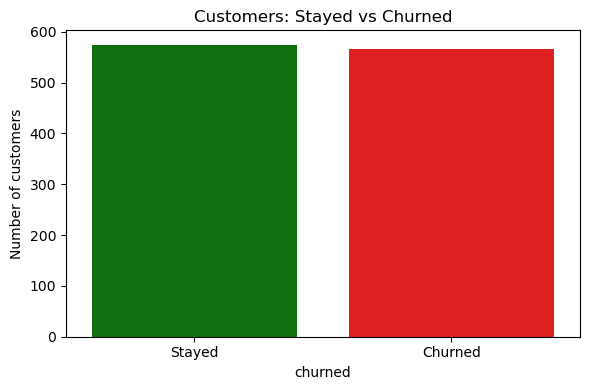

✅ Chart saved!


In [7]:
# Let's see how many customers churned vs stayed
# This is very important for model training

churn_counts = df['churned'].value_counts()
print("Churn distribution:")
print(f"  Stayed (0):  {churn_counts[0]} customers")
print(f"  Churned (1): {churn_counts[1]} customers")
print(f"  Churn rate:  {churn_counts[1]/len(df)*100:.1f}%")

# Draw a simple chart
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='churned', palette=['green', 'red'])
plt.title('Customers: Stayed vs Churned')
plt.xticks([0,1], ['Stayed', 'Churned'])
plt.ylabel('Number of customers')
plt.tight_layout()
plt.savefig('/tmp/churn_distribution.png')
plt.show()
print("✅ Chart saved!")

In [8]:
# We save our clean data back to S3
# So the next step (feature engineering) can read it

# Convert dataframe to CSV in memory
csv_buffer = io.StringIO()
df.to_csv(csv_buffer, index=False)

# Upload to S3
s3.put_object(
    Bucket=BUCKET_NAME,
    Key='data/cleaned/netflix_churn_cleaned.csv',
    Body=csv_buffer.getvalue()
)

print(f"✅ Clean data saved to S3!")
print(f"📁 Location: s3://{BUCKET_NAME}/data/cleaned/netflix_churn_cleaned.csv")
print(f"📊 Final shape: {df.shape}")
print(f"\n🎉 Step 1 Complete! Your data is clean and ready!")

✅ Clean data saved to S3!
📁 Location: s3://churn-mlops-project-cherry/data/cleaned/netflix_churn_cleaned.csv
📊 Final shape: (1139, 11)

🎉 Step 1 Complete! Your data is clean and ready!
